# Neutrino classification: a guided tour
**Chloe Lin · UCL · 2026 project**

How can a classifier score 88% accuracy while rejecting only 8% of background events? This walkthrough explains the problem, workflow and saved results, and reproduces the summary figure without restricted data.

**Reading time:** about 5 minutes. **No detector data or TensorFlow is needed to run this walkthrough.** It recomputes metrics from recorded confusion-matrix counts; it does not train or independently reproduce the classifier.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Run from the repository root or its notebooks directory.
ROOT = Path.cwd() if (Path.cwd() / "README.md").exists() else Path.cwd().parent
(ROOT / "figures").mkdir(exist_ok=True)
plt.rcParams.update({"figure.facecolor":"#f8fafc", "axes.facecolor":"#f8fafc",
                     "axes.spines.top":False, "axes.spines.right":False, "font.size":11})

## 1. From detector views to a classification task
The coursework used 21,016 simulated events from three HDF5 files. Each event has two 100 × 80 views, stacked as two channels. Signal comprises muon-neutrino charged-current interactions; other events form the background. Approximately 88.2% of events are signal.

**Workflow:** HDF5 images and labels → two-channel arrays → stratified 70/15/15 split → CNN → held-out evaluation.

The professor-provided dataset is deliberately absent. See [data access](../data/README.md).

## 2. Model and training decisions
The signal CNN has three convolutional blocks (16, 32, 64 filters), max pooling, a 64-unit dense layer, 30% dropout, and a sigmoid output. Training uses Adam and binary cross-entropy; early stopping monitors validation loss.

After the initial training stage, the same network received additional class-weighted training. This was an exploratory continuation, not a controlled comparison of freshly initialised models. The [full logbook](logbooks/neutrino_classification.ipynb) contains the implementation and extensions.

## 3. Reconstruct the saved evaluation
The test set contains 372 background and 2,781 signal events. Balanced accuracy is the average of their two recalls. The values below describe the historical run only.

In [2]:
# Counts transcribed from the saved coursework confusion matrices.
# Rows: true background/signal. Columns: predicted background/signal.
matrices = {"Unweighted": np.array([[31,341],[36,2745]]),
            "Additional weighted training": np.array([[339,33],[768,2013]])}
for label, cm in matrices.items():
    recall = np.diag(cm) / cm.sum(axis=1)
    print(f"{label}: accuracy={np.trace(cm)/cm.sum():.1%}; balanced accuracy={recall.mean():.1%}; background rejection={recall[0]:.1%}; signal recall={recall[1]:.1%}")
assert all(cm.sum()==3153 for cm in matrices.values())
assert np.array_equal(matrices["Unweighted"].sum(axis=1), matrices["Additional weighted training"].sum(axis=1))

Unweighted: accuracy=88.0%; balanced accuracy=53.5%; background rejection=8.3%; signal recall=98.7%
Additional weighted training: accuracy=74.6%; balanced accuracy=81.8%; background rejection=91.1%; signal recall=72.4%


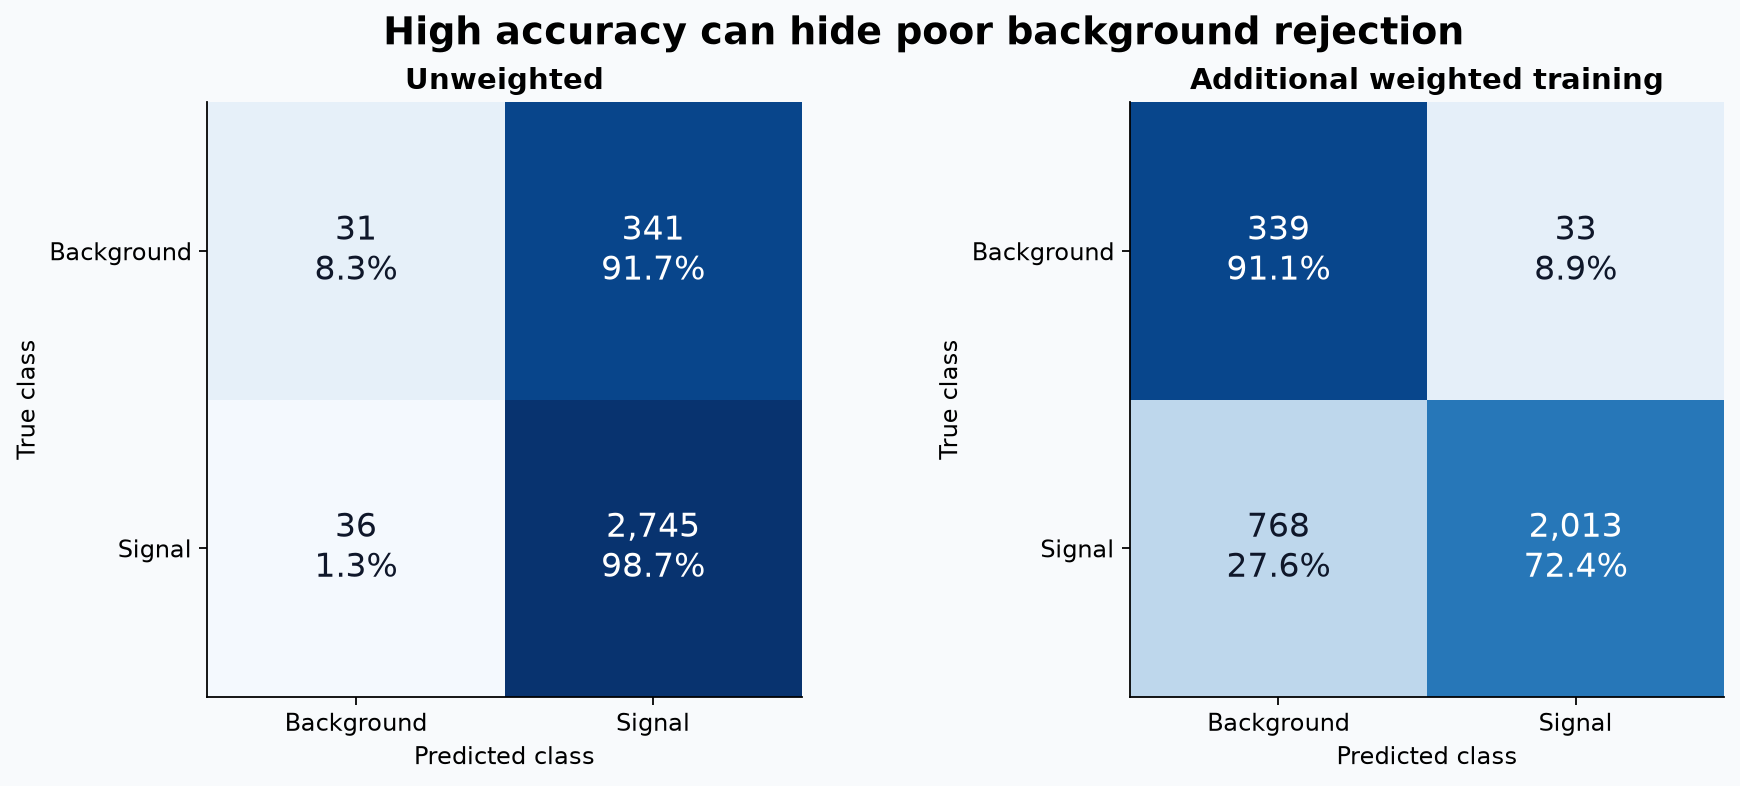

In [3]:
fig, axes = plt.subplots(1,2,figsize=(11.5,4.8),layout="constrained")
for ax, (title, cm) in zip(axes, matrices.items()):
    rates = cm / cm.sum(axis=1,keepdims=True)
    ax.imshow(rates, vmin=0, vmax=1, cmap="Blues")
    ax.set_xticks([0,1], ["Background","Signal"])
    ax.set_yticks([0,1], ["Background","Signal"])
    ax.set(xlabel="Predicted class",ylabel="True class",title=title)
    for i in range(2):
        for j in range(2):
            ax.text(j,i,f"{cm[i,j]:,}\n{rates[i,j]:.1%}",ha="center",va="center",fontsize=15,
                    color="white" if rates[i,j]>0.5 else "#0f172a")
fig.suptitle("High accuracy can hide poor background rejection",fontsize=17,fontweight="bold")
fig.savefig(ROOT / "figures/classification_comparison.png",dpi=160,bbox_inches="tight")

## 4. What changed?
Background rejection increased from **8.3% to 91.1%**, while signal recall fell from **98.7% to 72.4%**. Balanced accuracy increased from **53.5% to 81.8%**. A single overall accuracy hides this trade-off.

The saved ROC curve reports **AUC 0.879**. It cannot be reconstructed from a single confusion matrix; original prediction scores are required. See the original logbook for the saved curve.

Performance was also studied across neutrino/lepton energy, interaction types, and final states. Sparse bins require care; weak performance alone does not establish an intrinsic detector-information limit.

## 5. Extensions and remaining work
The original work also explores energy and energy-ratio regression, flavour classification, and interaction-mode classification. They illustrate task-specific losses, label design, and class imbalance, rather than uniformly strong predictive performance.

Before new headline claims, complete the [evaluation review](../docs/REVIEW_NOTES.md): training-only normalisation, aligned regression weights, fresh models for independent experiments, and a clean rerun. This presentation update does not resolve those historical modelling issues.

The aggregate figure is generated from saved counts, not event images. Existing logbook outputs remain private; permission to distribute data, sample images, or course-provided material must be clarified before publication.